In [1]:
from pathlib import Path
import sys

# Ensure project root is on sys.path for imports
project_root = Path.cwd()
while not (project_root / "main.py").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dataloader import load_illness_data

df = load_illness_data("SCZ", in_notebook=True)

Loading data for illness SCZ at /Users/leonackermann/Library/CloudStorage/GoogleDrive-leonmax.ackermann@googlemail.com/My Drive/Uni/Master/4/MasterThesis/ml-genetics4psychiatry/data/tmpDATA-Leon/donnees_MRI_SCZ_only_variants_clumping_p_thr_0.0001all.txt


In [2]:
from dataloader import preprocess

X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2)


In [11]:
# Test different alpha values
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0,1000.0,2000.0,3000,4000,5000,6000,7000,8000,9000,10000.0]
cv_scores = []

# Evaluate each alpha using 5-fold cross-validation
for alpha in alphas:
    # Create pipeline with scaling and Ridge
    pipeline = Pipeline([
        ("ridge", Ridge(alpha=alpha))
    ])
    
    # Perform cross-validation
    scores = cross_val_score(
        pipeline, X_train, y_train, 
        cv=5, 
        scoring="neg_mean_squared_error"
    )
    cv_scores.append(-scores.mean())

# Find the alpha with lowest cross-validation error
best_alpha = alphas[np.argmin(cv_scores)]

In [12]:
cv_scores

[np.float64(18.796085814132102),
 np.float64(18.787096350649403),
 np.float64(18.69979217769251),
 np.float64(18.001750271938185),
 np.float64(15.52656924921846),
 np.float64(13.39729716724787),
 np.float64(13.362360400071058),
 np.float64(13.72102992191384),
 np.float64(13.999611112587065),
 np.float64(14.223839965826238),
 np.float64(14.411252208496276),
 np.float64(14.572388333844174),
 np.float64(14.71390230100557),
 np.float64(14.840221371082041),
 np.float64(14.95442618071451),
 np.float64(15.058741629153317)]

In [13]:
# Create final pipeline with best alpha
final_pipeline = Pipeline([
    ("ridge", Ridge(alpha=best_alpha))
])

# Train on full training set
final_pipeline.fit(X_train, y_train)

# Make predictions on test set
y_pred = final_pipeline.predict(X_test)

# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [14]:
#print the results
print(f"Best alpha: {best_alpha}")
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R^2: {r2:.4f}")

Best alpha: 1000.0
Test MSE: 14.7748
Test RMSE: 3.8438
Test MAE: 3.3517
Test R^2: 0.3334


In [3]:
# create 10 models with different random seeds 
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  

seeds = np.arange(50)
results = []
for seed in seeds:
    X_train, y_train, X_test, y_test = preprocess(df=df, target="Z_scores_SCZ", testsize = 0.2, seed=seed)
    lasso = Ridge(alpha=1000.0  , random_state=seed, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_train = lasso.predict(X_train)
    y_pred_test = lasso.predict(X_test)
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    # extract the beta coefficients
    beta = lasso.coef_
    results.append((seed, train_mse, test_mse, train_r2, test_r2, beta))

In [5]:
# rank the most important features by the mean absolute value of their coefficients across the 10 models
import pandas as pd
columns = df.columns[:-2]  # all columns except the target
feature_importance = pd.DataFrame({
    "feature": columns,
    "importance": np.mean([np.abs(result[5]) for result in results], axis=0)
}).sort_values(by="importance", ascending=False)

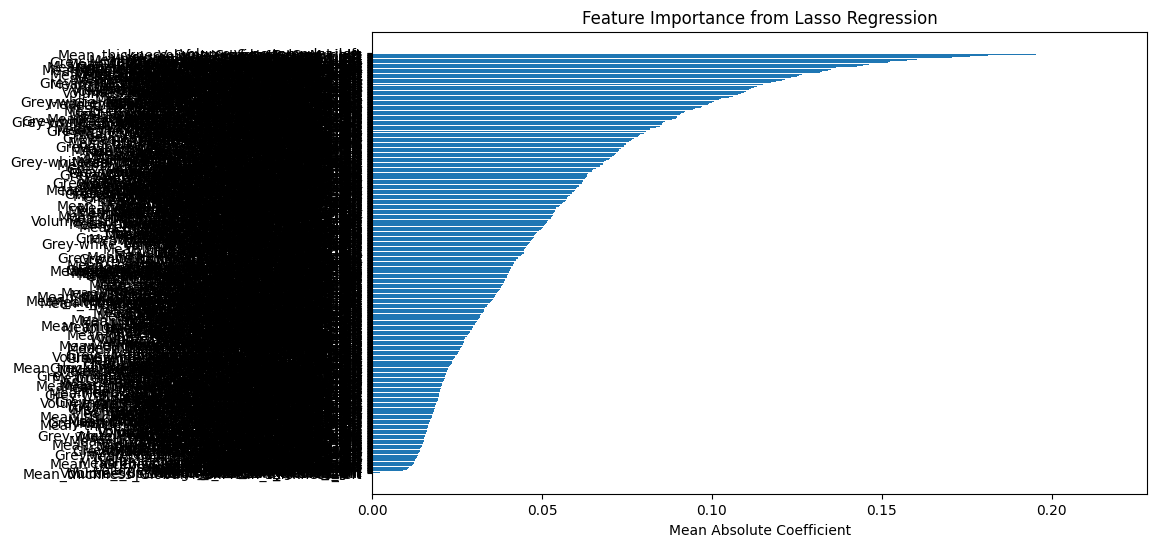

In [6]:
# plot the feature importance
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Mean Absolute Coefficient")
plt.title("Feature Importance from Lasso Regression")
plt.gca().invert_yaxis()
plt.show()

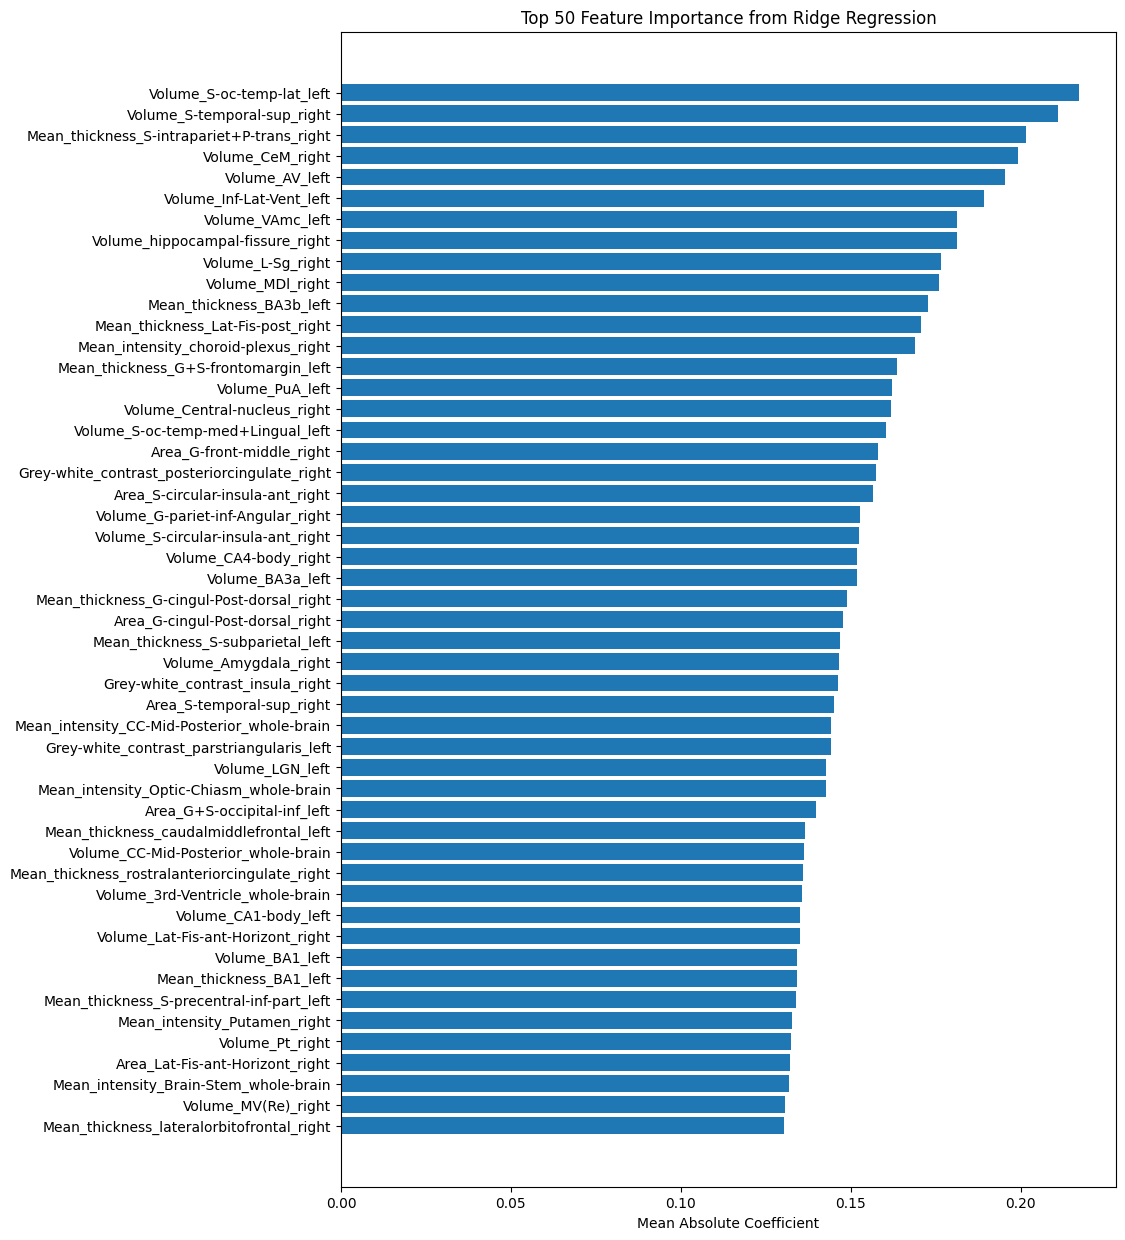

In [8]:
# plot most 50 important features
plt.figure(figsize=(10, 15))
plt.barh(feature_importance["feature"][:50], feature_importance["importance"][:50])
plt.xlabel("Mean Absolute Coefficient")
plt.title("Top 50 Feature Importance from Ridge Regression")
plt.gca().invert_yaxis()
plt.show()